x_train = [1.  1.5 2.  2.5 3.  3.5]
y_train = [300. 340. 400. 430. 480. 530.]
количество примеров: m = 6


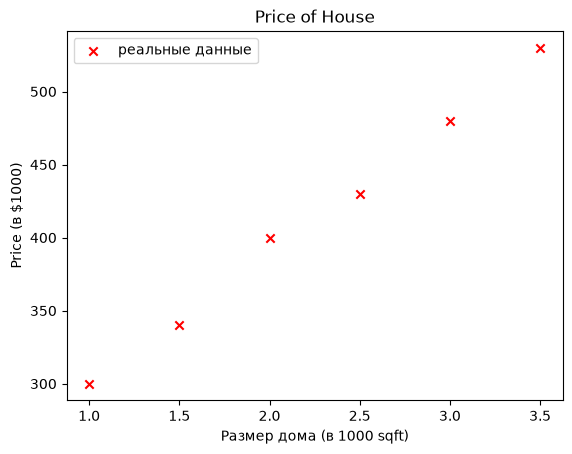

In [2]:
import numpy as np
import matplotlib.pyplot as plt


x_train = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
y_train = np.array([300.0, 340.0, 400.0, 430.0, 480.0, 530.0])

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")
print(f"количество примеров: m = {len(x_train)}")

plt.scatter(x_train, y_train, marker='x', c='r', label='реальные данные')
plt.title('Price of House')
plt.xlabel('Размер дома (в 1000 sqft)')
plt.ylabel('Price (в $1000)')
plt.legend()
plt.show()

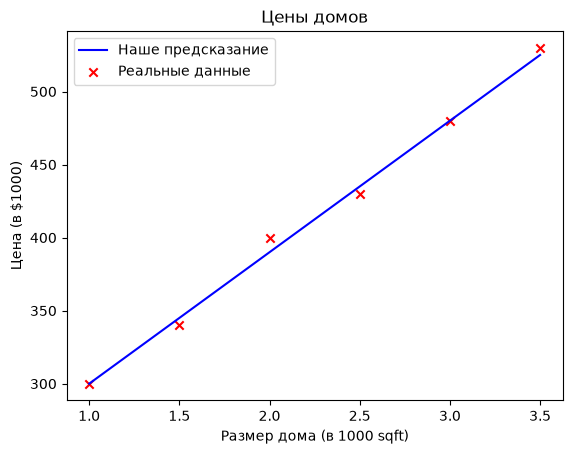

In [3]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = x[i] * w + b
    return f_wb

w = 90
b = 210

tmp_f_wb = compute_model_output(x_train, w, b)

plt.plot(x_train, tmp_f_wb, c='b', label='Наше предсказание')
plt.scatter(x_train, y_train, marker='x', c='r', label='Реальные данные')
plt.title("Цены домов")
plt.xlabel("Размер дома (в 1000 sqft)")
plt.ylabel("Цена (в $1000)")
plt.legend()
plt.show()


In [4]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb = x[i] * w + b
        cost = (f_wb - y[i]) ** 2
        cost_sum = cost_sum + cost
    total_cost = cost_sum / (2*m)
    return total_cost


cost = compute_cost(x_train, y_train, w=90, b=210)
print(f"Cost при w=90, b=210: {cost:2f}")

# Сравним с плохими параметрами
cost_bad = compute_cost(x_train, y_train, w=200, b=100)
print(f"Cost при w=200, b=100: {cost_bad:.2f}")

Cost при w=90, b=210: 14.583333
Cost при w=200, b=100: 13650.00


In [5]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = x[i] * w + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


dj_dw, dj_db = compute_gradient(x_train, y_train, w=200, b=100)
print(f"При w=200, b=100: dj_dw={dj_dw:.2f}, dj_db={dj_db:.2f}")

dj_dw, dj_db = compute_gradient(x_train, y_train, w=90, b=210)
print(f"При w=90, b=210: dj_dw={dj_dw:.2f}, dj_db={dj_db:.2f}")

При w=200, b=100: dj_dw=386.67, dj_db=136.67
При w=90, b=210: dj_dw=-2.92, dj_db=-0.83


In [6]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    w = w_in
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J_history.append(compute_cost(x, y, w, b))

        if i % 1000 == 0:
            print(f"Итерация {i:4}: Cost {J_history[-1]:8.2f}   w={w:.3f}, b={b:.3f}")
    return w, b, J_history


w_init = 0
b_init = 0
alpha = 0.01
iterations = 10000

w_final, b_final, J_hist = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)

Итерация    0: Cost 77230.33   w=9.967, b=4.133
Итерация 1000: Cost   169.26   w=111.100, b=157.938
Итерация 2000: Cost    31.04   w=98.031, b=190.944
Итерация 3000: Cost    15.47   w=93.644, b=202.023
Итерация 4000: Cost    13.71   w=92.172, b=205.741
Итерация 5000: Cost    13.52   w=91.678, b=206.989
Итерация 6000: Cost    13.49   w=91.512, b=207.407
Итерация 7000: Cost    13.49   w=91.457, b=207.548
Итерация 8000: Cost    13.49   w=91.438, b=207.595
Итерация 9000: Cost    13.49   w=91.432, b=207.611


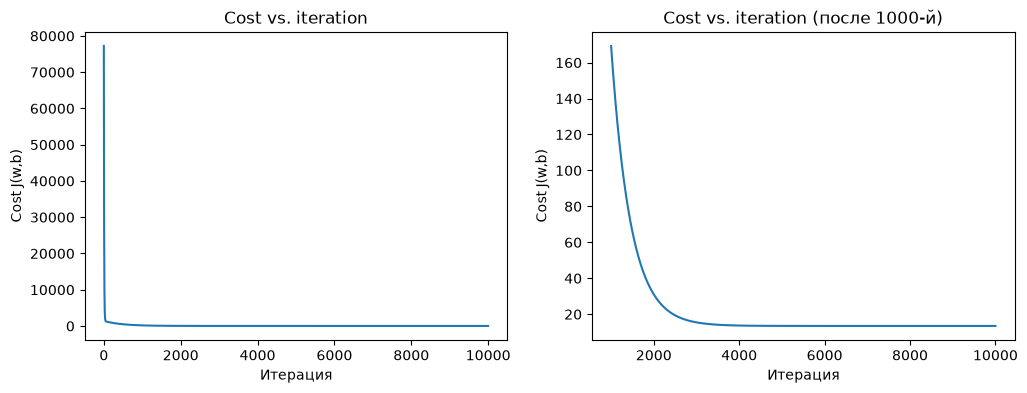

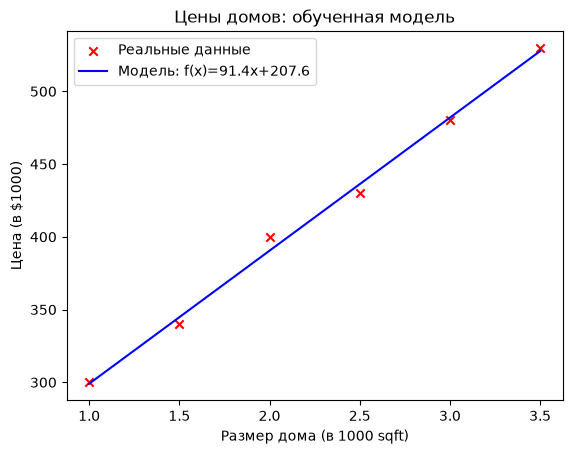

Дом размером 1.8 тыс. sqft: предсказанная цена = $372.2 тыс.


In [7]:
# График 1: как убывал cost по итерациям
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(J_hist)
ax1.set_title("Cost vs. iteration")
ax1.set_xlabel("Итерация")
ax1.set_ylabel("Cost J(w,b)")

# Увеличим последние итерации, там где уже "плоско" — тяжело разглядеть на общем графике
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax2.set_title("Cost vs. iteration (после 1000-й)")
ax2.set_xlabel("Итерация")
ax2.set_ylabel("Cost J(w,b)")

plt.show()

# График 2: итоговая прямая поверх реальных данных
predicted = w_final * x_train + b_final

plt.scatter(x_train, y_train, marker='x', c='r', label='Реальные данные')
plt.plot(x_train, predicted, c='b', label=f'Модель: f(x)={w_final:.1f}x+{b_final:.1f}')
plt.title("Цены домов: обученная модель")
plt.xlabel("Размер дома (в 1000 sqft)")
plt.ylabel("Цена (в $1000)")
plt.legend()
plt.show()

# Проверим предсказание на новом доме, которого не было в обучающих данных
new_size = 1.8
predicted_price = w_final * new_size + b_final
print(f"Дом размером {new_size} тыс. sqft: предсказанная цена = ${predicted_price:.1f} тыс.")

In [13]:
import numpy as np

X_train = np.array([
    [9.52, 3, 1, 40],
    [12.0, 3, 2, 15],
    [10.0, 3, 1, 25],
    [10.5, 2, 1, 20],
    [15.0, 4, 2, 5],
])

y_train = np.array([460, 540, 480, 430, 630])


print(f"X shape: {X_train.shape}")  # (m, n): m примеров, n признаков
print(f"y shape: {y_train.shape}")

w_init = np.zeros(X_train.shape[1])
b_init = 0.0

def predict(x, w, b):
    p = np.dot(x, w) + b
    return p

x_vec = X_train[0]
f_wb = predict(x_vec, w_init, b_init)
print(f"Предсказание при нулевых w, b: {f_wb}")

X shape: (5, 4)
y shape: (5,)
Предсказание при нулевых w, b: 0.0


In [14]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    f_wb = X @ w + b

    cost = np.sum((f_wb - y) ** 2) / (2*m)
    return cost

def compute_gradient(X, y, w, b):
    m = X.shape[0]

    f_wb = X @ w + b
    err = f_wb - y

    dj_dw = (X.T @ err) / m
    dj_db = np.sum(err) / m

    return dj_dw, dj_db

In [15]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J_history.append(compute_cost(X, y, w, b))

        if i % 100 == 0:
            print(f"Итерация {i:4}: Cost {J_history[-1]:8.2f}")
    return w, b, J_history

w_init = np.zeros(X_train.shape[1])
b_init = 0.0

w_final, b_final, J_hist = gradient_descent(X_train, y_train, w_init, b_init, alpha=0.01, num_iters=1000)
print(f"\nw_final: {w_final}")
print(f"b_final: {b_final}")

Итерация    0: Cost 3350940.06
Итерация  100: Cost 259651981863072405998037533249136061852174219694757277226039259239486577371486267105943264304345447844647537323065076109949234976151437642416876457273021431808.00
Итерация  200: Cost      inf
Итерация  300: Cost      inf
Итерация  400: Cost      inf
Итерация  500: Cost      nan
Итерация  600: Cost      nan
Итерация  700: Cost      nan
Итерация  800: Cost      nan
Итерация  900: Cost      nan

w_final: [nan nan nan nan]
b_final: nan


/tmp/ipykernel_3327/1432763805.py:6: RuntimeWarning: overflow encountered in square
  cost = np.sum((f_wb - y) ** 2) / (2*m)
/tmp/ipykernel_3327/1432763805.py:15: RuntimeWarning: overflow encountered in matmul
  dj_dw = (X.T @ err) / m
/tmp/ipykernel_3327/2669338941.py:8: RuntimeWarning: invalid value encountered in subtract
  w = w - alpha * dj_dw


In [16]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)

print("До нормализации (первая строка):", X_train[0])
print("После нормализации (первая строка):", X_norm[0])
print("mu:", X_mu)
print("sigma:", X_sigma)

До нормализации (первая строка): [ 9.52  3.    1.   40.  ]
После нормализации (первая строка): [-0.95097389  0.         -0.81649658  1.64135001]
mu: [11.404  3.     1.4   21.   ]
sigma: [ 1.98112695  0.63245553  0.48989795 11.5758369 ]


In [17]:
w_init = np.zeros(X_norm.shape[1])
b_init = 0.0

w_final, b_final, J_hist = gradient_descent(X_norm, y_train, w_init, b_init, alpha=0.1, num_iters=1000)

print(f"\nw_final: {w_final}")
print(f"b_final: {b_final}")

Итерация    0: Cost 105741.64
Итерация  100: Cost     0.79
Итерация  200: Cost     0.38
Итерация  300: Cost     0.18
Итерация  400: Cost     0.09
Итерация  500: Cost     0.04
Итерация  600: Cost     0.02
Итерация  700: Cost     0.01
Итерация  800: Cost     0.00
Итерация  900: Cost     0.00

w_final: [ 13.31270503  37.18487637  17.39890219 -12.84747093]
b_final: 507.9999999999998


In [18]:
x_new = np.array([12.0, 3, 1, 30])

x_new_norm = (x_new - X_mu) / X_sigma

predicted_price = x_new_norm @ w_final + b_final

print(f"Ненормализованный x_new: {x_new}")
print(f"Нормализованный x_new:   {x_new_norm}")
print(f"Предсказанная цена: ${predicted_price:.1f} тыс.")

wrong_prediction = x_new @ w_final + b_final
print(f"\nОШИБКА, если забыть нормализовать: ${wrong_prediction:.1f} тыс. (бессмысленное число)")

Ненормализованный x_new: [12.  3.  1. 30.]
Нормализованный x_new:   [ 0.30083887  0.         -0.81649658  0.77748158]
Предсказанная цена: $487.8 тыс.

ОШИБКА, если забыть нормализовать: $411.3 тыс. (бессмысленное число)


In [19]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm_sklearn = scaler.fit_transform(X_train)

print("mu (sklearn):   ", scaler.mean_)
print("sigma (sklearn): ", scaler.scale_)
print("Наши mu, sigma:  ", X_mu, X_sigma)

sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm_sklearn, y_train)

print(f"\nКоличество итераций до сходимости: {sgdr.n_iter_}")
print(f"w (sklearn): {sgdr.coef_}")
print(f"b (sklearn): {sgdr.intercept_}")
print(f"\nНаши w_final: {w_final}")
print(f"Наш b_final:  {b_final}")

mu (sklearn):    [11.404  3.     1.4   21.   ]
sigma (sklearn):  [ 1.98112695  0.63245553  0.48989795 11.5758369 ]
Наши mu, sigma:   [11.404  3.     1.4   21.   ] [ 1.98112695  0.63245553  0.48989795 11.5758369 ]

Количество итераций до сходимости: 936
w (sklearn): [18.64364433 34.71084892 17.43044215 -9.01057953]
b (sklearn): [507.73616539]

Наши w_final: [ 13.31270503  37.18487637  17.39890219 -12.84747093]
Наш b_final:  507.9999999999998


In [22]:
x_new = np.array([[12.0, 3, 1, 30]])  # обрати внимание — 2D массив, sklearn этого требует
x_new_scaled = scaler.transform(x_new)

predicted_sklearn = sgdr.predict(x_new_scaled)

print(f"Предсказание sklearn: ${predicted_sklearn[0]:.1f} тыс.")
print(f"Наше предсказание:    $487.8 тыс.")

Предсказание sklearn: $492.1 тыс.
Наше предсказание:    $487.8 тыс.


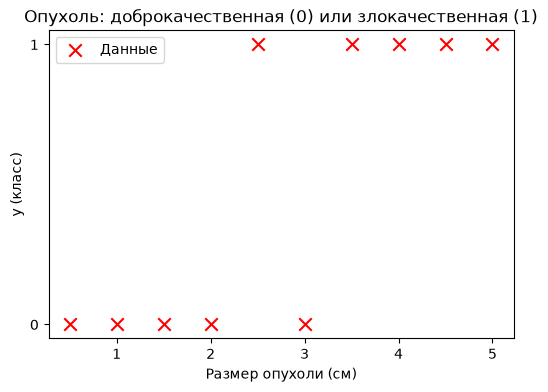

In [23]:
import numpy as np 
import matplotlib.pyplot as plt


x_train = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
y_train = np.array([0,   0,   0,   0,   1,   0,   1,   1,   1,   1])

plt.figure(figsize=(6,4))
plt.scatter(x_train, y_train, marker='x', c='r', s=80, label='Данные')
plt.title("Опухоль: доброкачественная (0) или злокачественная (1)")
plt.xlabel("Размер опухоли (см)")
plt.ylabel("y (класс)")
plt.yticks([0,1])
plt.legend()
plt.show()